# Lab: Uniswap V2 AMM — Implementation & Analysis

**Prerequisites:** Python 3.10+, `matplotlib`, `numpy`  
**Estimated time:** 2 hours

---

## Introduction

Most DeFi protocols are built on top of one core primitive: the **Automated Market Maker (AMM)**. Instead of matching buyers and sellers through an order book, an AMM uses a mathematical formula to determine prices algorithmically.

Uniswap V2 uses the **constant product formula**:

$$x \cdot y = k$$

Where `x` and `y` are the reserves of two tokens in a pool, and `k` is a constant that must hold after every trade (accounting for fees). This deceptively simple equation encodes all the pool's behavior: pricing, slippage, liquidity incentives.

In this lab you will:
1. Implement a working AMM pool from scratch
2. Analyze how trade size affects price
3. Model liquidity provision and fee accrual

In [1]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

---

## Part 1 — Pool Mechanics

### 1.1 The `UniswapV2Pool` Class

Implement the pool. The constructor takes initial reserves and a fee in **basis points** (1 bps = 0.01%, so the default 30 bps = 0.3%).

**Task 1.1** — Implement all properties. Verify with a sanity check: pool with `reserve_x=1000, reserve_y=2_000_000` should have `price = 2000.0` and `k = 2_000_000_000`.

In [2]:
class UniswapV2Pool:
    def __init__(self, reserve_x: float, reserve_y: float, fee_bps: int = 30):
        self.reserve_x = float(reserve_x)
        self.reserve_y = float(reserve_y)
        self.fee_bps = int(fee_bps)

        self.total_shares = 0.0
        self.lp_positions = {}
        self.lp_entry_k = {}

    @property
    def k(self) -> float:
        return self.reserve_x * self.reserve_y

    @property
    def price(self) -> float:
        # spot price of X denominated in Y
        return self.reserve_y / self.reserve_x

    @property
    def fee_rate(self) -> float:
        # convert basis points to decimal: 30 bps = 0.003
        return self.fee_bps / 10_000

    def get_amount_out(self, amount_in: float, token: str) -> float:
        assert token in ('x', 'y')
        assert amount_in >= 0, "amount_in must be non-negative"

        if token == 'x':
            reserve_in, reserve_out = self.reserve_x, self.reserve_y
        else:
            reserve_in, reserve_out = self.reserve_y, self.reserve_x

        amount_in_with_fee = amount_in * (1 - self.fee_rate)
        return (reserve_out * amount_in_with_fee) / (reserve_in + amount_in_with_fee)

    def swap(self, amount_in: float, token: str) -> float:
        assert token in ('x', 'y')
        assert amount_in > 0, "swap amount must be positive"

        k_before = self.k
        amount_out = self.get_amount_out(amount_in, token)

        if token == 'x':
            assert amount_out < self.reserve_y, "insufficient Y liquidity"
            self.reserve_x += amount_in
            self.reserve_y -= amount_out
        else:
            assert amount_out < self.reserve_x, "insufficient X liquidity"
            self.reserve_y += amount_in
            self.reserve_x -= amount_out

        assert self.k >= k_before - 1e-9, "Invariant violated!"
        return amount_out

    def __repr__(self) -> str:
        return (
            f"UniswapV2Pool(reserve_x={self.reserve_x:.6f}, "
            f"reserve_y={self.reserve_y:.6f}, fee_bps={self.fee_bps}, "
            f"k={self.k:.6f}, price={self.price:.6f})"
        )


#### Sanity check — Task 1.1

Create a pool with `reserve_x=1000, reserve_y=2_000_000` and verify `price == 2000.0` and `k == 2_000_000_000`.

In [3]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)

print("Spot price:", pool.price)
print("k:", pool.k)
print(pool)

assert pool.price == 2000.0
assert pool.k == 2_000_000_000


Spot price: 2000.0
k: 2000000000.0
UniswapV2Pool(reserve_x=1000.000000, reserve_y=2000000.000000, fee_bps=30, k=2000000000.000000, price=2000.000000)


---

### 1.2 Computing `get_amount_out`

The formula accounts for the fee taken on the input side:

$$\text{amount\_in\_with\_fee} = \text{amount\_in} \times (1 - \text{fee\_rate})$$

$$\text{amount\_out} = \frac{\text{reserve\_out} \times \text{amount\_in\_with\_fee}}{\text{reserve\_in} + \text{amount\_in\_with\_fee}}$$

This is derived directly from $x \cdot y = k$ — solve for the new reserve after the swap, take the difference. The fee is *not* returned to the sender; it stays in the pool.

**Task 1.2** — Go back to the class cell above and implement `get_amount_out`. Then verify by hand: pool is `100 X / 100 Y` (price = 1.0), fee = 0%, swap 10 X. You should receive exactly `9.09...` Y, not 10. Why?

In [4]:
pool_no_fee = UniswapV2Pool(reserve_x=100, reserve_y=100, fee_bps=0)
amount_out = pool_no_fee.get_amount_out(10, 'x')

print("Amount out for 10 X -> Y (no fee):", amount_out)
assert abs(amount_out - 9.0909090909) < 1e-6

# The output is still less than 10 because the AMM must preserve x*y=k.
# As X is added, the marginal price moves along the convex constant-product curve,
# so the trader receives a worse average price than the initial spot price.


Amount out for 10 X -> Y (no fee): 9.090909090909092


---

### 1.3 Executing a Swap

**Task 1.3** — Go back to the class cell above and implement `swap`. Then run 1000 random swaps and assert `k` never decreases. Print `k` before and after the full run — does it grow? Why does it sometimes *increase*? Where do the fees go?

In [5]:
random.seed(42)

pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000, fee_bps=30)
k_initial = pool.k
k_prev = k_initial

for _ in range(1000):
    token = random.choice(['x', 'y'])
    reserve_in = pool.reserve_x if token == 'x' else pool.reserve_y
    amount_in = random.uniform(1e-9, 0.02 * reserve_in)

    pool.swap(amount_in, token)

    assert pool.k >= k_prev - 1e-9
    k_prev = pool.k

k_final = pool.k

print(f"k_initial = {k_initial:.6f}")
print(f"k_final   = {k_final:.6f}")
print(f"Growth factor = {k_final / k_initial:.6f}x")


k_initial = 2000000000.000000
k_final   = 2061392052.390908
Growth factor = 1.030696x


`k` grows over time because the swap fee is taken from the input token and left inside the pool.  
The trader receives output computed from `amount_in_with_fee`, but the full `amount_in` is added to reserves.  
Therefore the pool keeps a small surplus on every trade, and that surplus increases the reserve product `k`.

The fees do not go to a separate wallet during the swap. They remain embedded in pool reserves, which is why LPs earn when they later withdraw.

If `fee_bps = 0`, then in exact algebra `k` stays constant after swaps. In practice it may change by an extremely tiny amount only because of floating-point rounding, not because the AMM is generating value.


---

## Part 2 — Price Impact

Price impact is the difference between the price you *expected* (spot price before the trade) and the price you *actually got* (execution price).

$$\text{price\_impact} = \frac{p_{\text{spot}} - p_{\text{execution}}}{p_{\text{spot}}}$$

For a swap X → Y:
- Spot price: `reserve_y / reserve_x`
- Execution price: `amount_out / amount_in`

### 2.1 Single Swap Analysis

**Task 2.1** — Compute spot price, execution price, and price impact for `amount_in = 1, 10, 50, 100` ETH. Fill in the table below.

In [6]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)  # 1 ETH = 2000 USDC

results = []
for amount_in in [1, 10, 50, 100]:
    spot_price = pool.price
    amount_out = pool.get_amount_out(amount_in, 'x')   # do NOT mutate state
    exec_price = amount_out / amount_in
    price_impact = (spot_price - exec_price) / spot_price * 100
    results.append((amount_in, spot_price, exec_price, price_impact))

for row in results:
    print(
        f"amount_in={row[0]:>3} ETH | "
        f"spot={row[1]:.2f} | exec={row[2]:.4f} | impact={row[3]:.4f}%"
    )


amount_in=  1 ETH | spot=2000.00 | exec=1992.0140 | impact=0.3993%
amount_in= 10 ETH | spot=2000.00 | exec=1974.3161 | impact=1.2842%
amount_in= 50 ETH | spot=2000.00 | exec=1899.3190 | impact=5.0341%
amount_in=100 ETH | spot=2000.00 | exec=1813.2218 | impact=9.3389%


**Fill in the table:**

| Amount In (ETH) | Spot Price | Exec Price | Price Impact |
|---|---:|---:|---:|
| 1 | 2000.00 | 1992.0140 | 0.3993% |
| 10 | 2000.00 | 1974.3161 | 1.2842% |
| 50 | 2000.00 | 1899.3190 | 5.0341% |
| 100 | 2000.00 | 1813.2218 | 9.3389% |

---

### 2.2 Experiment: Swap Size vs Price Impact

Sweep `amount_in` from 0.1 ETH to 500 ETH and plot the price impact curve.

**Task 2.2** — Create the plot with:
- Price impact (%) on y-axis vs trade size as % of `reserve_x` on x-axis
- Horizontal dashed lines at 1% and 5% impact
- Axis labels, title, legend, grid

1% impact crossed at ~0.846% of pool
5% impact crossed at ~5.026% of pool


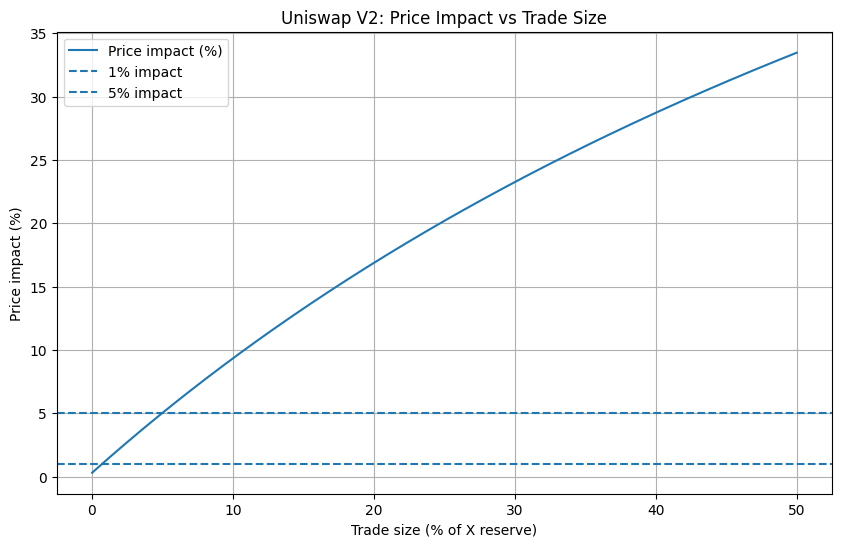

In [ ]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)
sizes = np.linspace(0.1, 500, 300)

impacts_pct = []
trade_size_pct_of_pool = []

for size in sizes:
    amount_out = pool.get_amount_out(size, 'x')
    exec_price = amount_out / size
    price_impact = (pool.price - exec_price) / pool.price * 100

    impacts_pct.append(price_impact)
    trade_size_pct_of_pool.append(size / pool.reserve_x * 100)

impacts_pct = np.array(impacts_pct)
trade_size_pct_of_pool = np.array(trade_size_pct_of_pool)

cross_1_idx = np.argmax(impacts_pct >= 1.0)
cross_5_idx = np.argmax(impacts_pct >= 5.0)

print(f"1% impact crossed at ~{trade_size_pct_of_pool[cross_1_idx]:.3f}% of pool")
print(f"5% impact crossed at ~{trade_size_pct_of_pool[cross_5_idx]:.3f}% of pool")

plt.plot(trade_size_pct_of_pool, impacts_pct, label="Price impact (%)")
plt.axhline(1.0, linestyle="--", label="1% impact")
plt.axhline(5.0, linestyle="--", label="5% impact")
plt.xlabel("Trade size (% of X reserve)")
plt.ylabel("Price impact (%)")
plt.title("Uniswap V2: Price Impact vs Trade Size")
plt.legend()
plt.grid(True)
plt.show()


**Research questions (Task 2.2):**
- At what trade size (as % of pool) does price impact cross 1%? Cross 5%?
- Is the curve linear or convex? Explain why from the formula.
- At 10% of pool size, what is the approximate impact? Is this acceptable for a DEX user?

From the plot, price impact crosses **1%** at about **0.85% of the pool**, and it crosses **5%** at about **5.03% of the pool**.

The curve is **convex**, not linear. The execution price follows the rational AMM formula  
`amount_out = reserve_out * in_eff / (reserve_in + in_eff)`, so each additional unit traded moves the reserves further along the constant-product curve and worsens the marginal price faster than linearly.

At **10% of pool size** (about **100 ETH** into a 1000 ETH pool), the impact is about **9.34%**. For most traders this is very expensive and usually unacceptable unless the trade is urgent or there is no deeper liquidity elsewhere.


---

### 2.3 Experiment: Pool Depth vs Price Impact

Fix the trade at \$10,000. Vary pool TVL from \$100k to \$100M and observe how pool depth affects price.

**Task 2.3** — Create the plot with:
- Price impact (%) on y-axis vs TVL (\$) on x-axis with log scale on x
- Horizontal dashed lines at 0.1% and 1.0%
- Axis labels, title, legend, grid

First TVL below 1.0% impact: $2,848,035.87


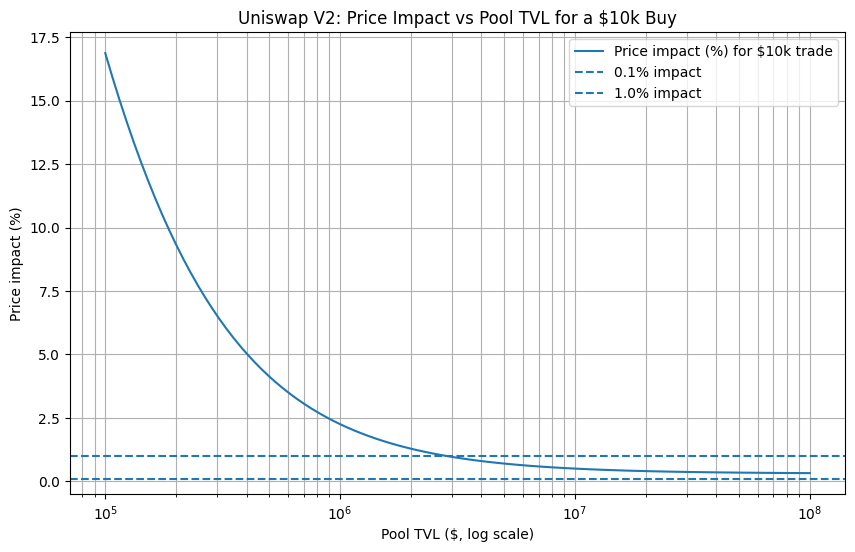

In [7]:
trade_size_usd = 10_000
price_eth = 2000
tvl_values = np.logspace(5, 8, 100)  # $100k -> $100M on log scale

impacts_pct = []

for tvl in tvl_values:
    reserve_y = tvl / 2                 # USDC side
    reserve_x = reserve_y / price_eth   # ETH side at 2000 USDC/ETH

    pool = UniswapV2Pool(reserve_x=reserve_x, reserve_y=reserve_y, fee_bps=30)

    amount_in_eth = trade_size_usd / price_eth
    amount_out = pool.get_amount_out(amount_in_eth, 'x')
    exec_price = amount_out / amount_in_eth
    price_impact = (pool.price - exec_price) / pool.price * 100

    impacts_pct.append(price_impact)

impacts_pct = np.array(impacts_pct)

below_1_mask = impacts_pct <= 1.0
if below_1_mask.any():
    first_tvl_below_1 = tvl_values[below_1_mask][0]
    print(f"First TVL below 1.0% impact: ${first_tvl_below_1:,.2f}")

plt.semilogx(tvl_values, impacts_pct, label="Price impact (%) for $10k trade")
plt.axhline(0.1, linestyle="--", label="0.1% impact")
plt.axhline(1.0, linestyle="--", label="1.0% impact")
plt.xlabel("Pool TVL ($, log scale)")
plt.ylabel("Price impact (%)")
plt.title("Uniswap V2: Price Impact vs Pool TVL for a $10k Buy")
plt.legend()
plt.grid(True, which="both")
plt.show()


**Research questions (Task 2.3):**
- What minimum TVL keeps impact below 0.1% for a \$10k trade?
- If trade size doubles, how does required TVL change?
- Real Uniswap V2 ETH/USDC had ~\$300M TVL at peak. Estimate the impact for a \$1M trade.

With a **30 bps fee**, there is **no finite TVL** that can push total impact below **0.1%** for a $10k trade, because the fee alone already contributes **0.3%** before slippage is even considered. In other words, the 0.1% target is unattainable in this setup.

If the trade size doubles and you want to keep roughly the same slippage component, the required TVL scales **approximately linearly**. That is because impact is driven mainly by the ratio `trade_size / reserve`, so doubling the trade usually requires roughly doubling liquidity.

For a pool with **$300M TVL**, a **$1M trade** corresponds to about **500 ETH** at $2000/ETH. The estimated total impact is about **0.96%** in this model, which is quite reasonable for a trade of that size.


---

### 2.4 Bonus: Comparing Fee Tiers

**Task 2.4** — Plot price impact for three fee tiers (0.05%, 0.3%, 1.0%) on the same axes. At what trade size does the fee start to dominate slippage as the main cost?

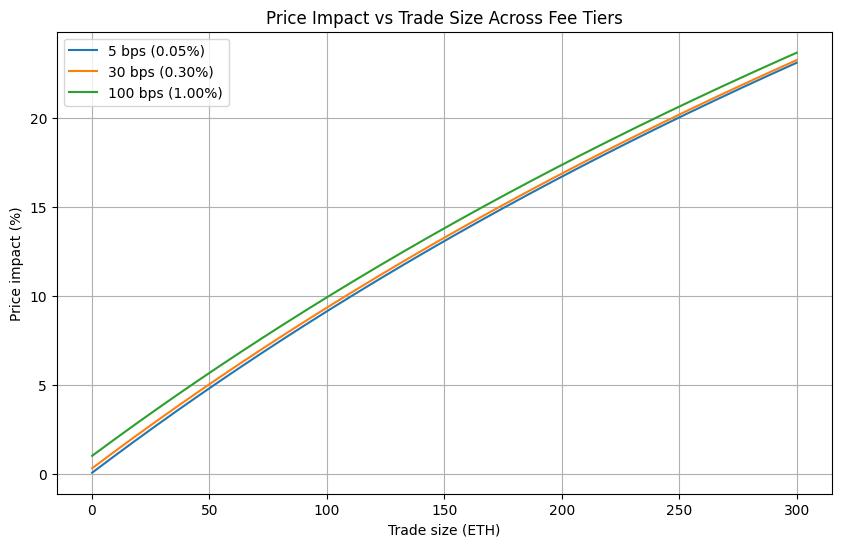

In [8]:
fee_tiers = [5, 30, 100]   # 0.05%, 0.3%, 1.0%
sizes = np.linspace(0.1, 300, 200)

for fee in fee_tiers:
    pool = UniswapV2Pool(1000, 2_000_000, fee_bps=fee)
    impacts_pct = []

    for size in sizes:
        amount_out = pool.get_amount_out(size, 'x')
        exec_price = amount_out / size
        price_impact = (pool.price - exec_price) / pool.price * 100
        impacts_pct.append(price_impact)

    plt.plot(sizes, impacts_pct, label=f"{fee} bps ({fee/100:.2f}%)")

plt.xlabel("Trade size (ETH)")
plt.ylabel("Price impact (%)")
plt.title("Price Impact vs Trade Size Across Fee Tiers")
plt.legend()
plt.grid(True)
plt.show()


**Research question (Task 2.4):**

At what trade size does the fee start to dominate slippage as the main cost? What does this mean for a trader choosing between pools?

For **small trades**, the **fee dominates** the total trading cost because slippage is still tiny while the fee is a fixed percentage of input. In this setup, that means the **100 bps** pool is expensive almost immediately, the **30 bps** pool dominates cost for modest trades, and only for **larger trades** does curve slippage become comparable to or larger than the fee.

Practically, this means traders should prefer the **lowest-fee pool that still has enough liquidity**. A low-fee pool is best for small, frequent trades, but a deeper higher-fee pool can still be cheaper for a large order if its extra liquidity reduces slippage enough to offset the higher fee.
